In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

### Task 1 — Load & Inspect the Data (Red + White)

## 1. Load both CSV fi les using sep=";"

In [3]:
wq_red = pd.read_csv('/content/sample_data/winequality-red.csv', sep=';')
wq_white = pd.read_csv('/content/sample_data/winequality-white.csv', sep=';')

# shape (rows, cols)

In [4]:
np.shape(wq_red)

(1599, 12)

In [6]:
np.shape(wq_white)

(4898, 12)

# First 5 rows

In [9]:
wq_red.head(5)

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [10]:
wq_white.head(5)

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.0,0.27,0.36,20.7,0.045,45.0,170.0,1.0010,3.00,0.45,8.8,6
1,6.3,0.30,0.34,1.6,0.049,14.0,132.0,0.9940,3.30,0.49,9.5,6
2,8.1,0.28,0.40,6.9,0.050,30.0,97.0,0.9951,3.26,0.44,10.1,6
3,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6
4,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6


# Column List

In [11]:
wq_red.columns

Index(['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar',
       'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density',
       'pH', 'sulphates', 'alcohol', 'quality'],
      dtype='object')

In [12]:
wq_white.columns

Index(['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar',
       'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density',
       'pH', 'sulphates', 'alcohol', 'quality'],
      dtype='object')

## 3. Verify the target column quality exists.

In [17]:
'quality' in wq_red.columns

True

In [18]:
'quality' in wq_white.columns

True

## Deliverables

1. Data loaded successfully
2. Target column is present in both the tables.

### Task 2 — Data Quality Checks + Class Distribution (Comparative)

## 1. Check missing values per column.

In [20]:
wq_red.isnull().sum()

,0
fixed acidity,0
volatile acidity,0
citric acid,0
residual sugar,0
chlorides,0
free sulfur dioxide,0
total sulfur dioxide,0
density,0
pH,0
sulphates,0


In [21]:
wq_white.isnull().sum()

,0
fixed acidity,0
volatile acidity,0
citric acid,0
residual sugar,0
chlorides,0
free sulfur dioxide,0
total sulfur dioxide,0
density,0
pH,0
sulphates,0


## 2. Check duplicates

In [22]:
wq_red.duplicated().sum()

np.int64(240)

In [23]:
wq_white.duplicated().sum()

np.int64(937)

In [24]:
wq_red = wq_red.drop_duplicates()
wq_white = wq_white.drop_duplicates()

In [25]:
wq_white.duplicated().sum()

np.int64(0)

In [26]:
wq_red.duplicated().sum()

np.int64(0)

## 3. Show quality class distribution:

○ counts

○ percentages

In [30]:
wq_red['quality'].value_counts().sort_index()

,count
quality,
3,10
4,53
5,577
6,535
7,167
8,17


In [31]:
wq_white['quality'].value_counts().sort_index()

,count
quality,
3,20
4,153
5,1175
6,1788
7,689
8,131
9,5


In [35]:
wq_red['quality'].value_counts(normalize=True).sort_index()*100

,proportion
quality,
3,0.735835
4,3.899926
5,42.457689
6,39.367182
7,12.288447
8,1.250920


In [36]:
wq_white['quality'].value_counts(normalize=True).sort_index() * 100

,proportion
quality,
3,0.504923
4,3.862661
5,29.664226
6,45.140116
7,17.394597
8,3.307246
9,0.126231


## 4. Plot a bar chart of quality counts.

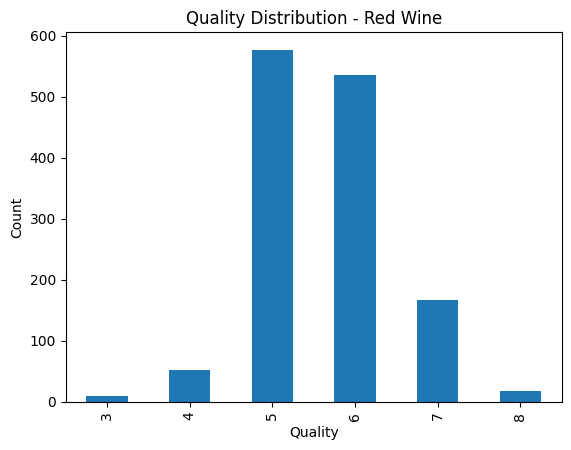

In [37]:
wq_red['quality'].value_counts().sort_index().plot(kind='bar')
plt.title('Quality Distribution - Red Wine')
plt.xlabel('Quality')
plt.ylabel('Count')
plt.show()

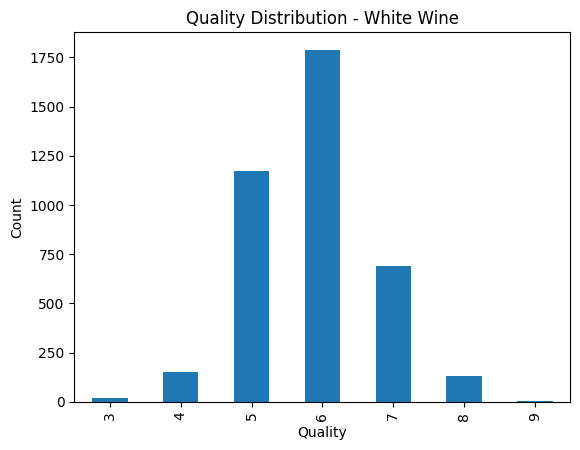

In [38]:
wq_white['quality'].value_counts().sort_index().plot(kind='bar')
plt.title('Quality Distribution - White Wine')
plt.xlabel('Quality')
plt.ylabel('Count')
plt.show()

## Comparative Questions (answer in 4–6 lines)

● Which dataset is more imbalanced?

White wine is generally more imbalanced than red wine, as most samples are concentrated around mid-range quality scores (like 5–7), with fewer extreme values.

● Which quality classes are rare?

Rare classes in both datasets are the lowest and highest quality scores (e.g., 3, 4, 8, 9).
These rare classes have very few examples, making it difficult for models to learn their patterns effectively.

● Why might rare classes be harder to predict?

As a result, models tend to be biased toward majority classes and may misclassify rare ones.This leads to poorer prediction performance, especially for extreme quality wines.

### Task 3 — Prepare Data for Modeling (Same Setup for Fair Comparison)

##

In [39]:
X_red = wq_red.drop('quality', axis=1)
y_red = wq_red['quality']

In [40]:
X_red.columns

Index(['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar',
       'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density',
       'pH', 'sulphates', 'alcohol'],
      dtype='object')

In [41]:
X_red_train, X_red_test, y_red_train, y_red_test = train_test_split(X_red, y_red,test_size=0.2,random_state=42,stratify=y_red)

In [42]:
X_white = wq_white.drop('quality', axis=1)
y_white = wq_white['quality']

In [44]:
X_white.columns

Index(['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar',
       'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density',
       'pH', 'sulphates', 'alcohol'],
      dtype='object')

In [45]:
X_white_train, X_white_test, y_white_train, y_white_test = train_test_split(X_white, y_white,test_size=0.2,random_state=42,stratify=y_white)

### Task 4 — Model A (Baseline): Logistic Regression (Red vs White)

In [47]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

In [48]:
pipeline_red = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(max_iter=5000))
])

In [49]:
pipeline_red.fit(X_red_train, y_red_train)

Pipeline(steps=[('scaler', StandardScaler()),
                ('model', LogisticRegression(max_iter=5000))])

In [50]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, f1_score

In [51]:
y_red_pred = pipeline_red.predict(X_red_test)

In [52]:
print("Accuracy:", accuracy_score(y_red_test, y_red_pred))
print("Confusion Matrix:\n", confusion_matrix(y_red_test, y_red_pred))
print("Classification Report:\n", classification_report(y_red_test, y_red_pred))

Accuracy: 0.5808823529411765
Confusion Matrix:
 [[ 0  0  1  1  0  0]
 [ 0  0 11  0  0  0]
 [ 0  0 85 31  0  0]
 [ 0  0 37 64  6  0]
 [ 0  0  2 22  9  0]
 [ 0  0  0  2  1  0]]
Classification Report:
               precision    recall  f1-score   support

           3       0.00      0.00      0.00         2
           4       0.00      0.00      0.00        11
           5       0.62      0.73      0.67       116
           6       0.53      0.60      0.56       107
           7       0.56      0.27      0.37        33
           8       0.00      0.00      0.00         3

    accuracy                           0.58       272
   macro avg       0.29      0.27      0.27       272
weighted avg       0.54      0.58      0.55       272



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [53]:
f1_red = f1_score(y_red_test, y_red_pred, average='macro')
print("Macro F1-score:", f1_red)

Macro F1-score: 0.267637794226844


In [54]:
pipeline_white = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(max_iter=5000))
])

In [55]:
pipeline_white.fit(X_white_train, y_white_train)

Pipeline(steps=[('scaler', StandardScaler()),
                ('model', LogisticRegression(max_iter=5000))])

In [56]:
y_white_pred = pipeline_white.predict(X_white_test)

In [58]:
print("Accuracy:", accuracy_score(y_white_test, y_white_pred))
print("Confusion Matrix:\n", confusion_matrix(y_white_test, y_white_pred))
print("Classification Report:\n", classification_report(y_white_test, y_white_pred))

Accuracy: 0.5296343001261034
Confusion Matrix:
 [[  0   0   1   3   0   0   0]
 [  0   1  18  12   0   0   0]
 [  0   1 123 108   3   0   0]
 [  0   1  73 261  23   0   0]
 [  0   0   2 101  35   0   0]
 [  0   0   1  18   7   0   0]
 [  0   0   0   0   1   0   0]]
Classification Report:
               precision    recall  f1-score   support

           3       0.00      0.00      0.00         4
           4       0.33      0.03      0.06        31
           5       0.56      0.52      0.54       235
           6       0.52      0.73      0.61       358
           7       0.51      0.25      0.34       138
           8       0.00      0.00      0.00        26
           9       0.00      0.00      0.00         1

    accuracy                           0.53       793
   macro avg       0.27      0.22      0.22       793
weighted avg       0.50      0.53      0.50       793



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [59]:
f1_white = f1_score(y_white_test, y_white_pred, average='macro')
print("Macro F1-score:", f1_white)

Macro F1-score: 0.22090084503412463


### Task 5 — Model B (Tree Model): Random Forest (Red vs White)

In [60]:
from sklearn.ensemble import RandomForestClassifier

In [61]:
rf_red = RandomForestClassifier(n_estimators=300, random_state=42)
rf_red.fit(X_red_train, y_red_train)

RandomForestClassifier(n_estimators=300, random_state=42)

In [62]:
y_red_pred_rf = rf_red.predict(X_red_test)

In [63]:
print("Accuracy:", accuracy_score(y_red_test, y_red_pred_rf))
print("Confusion Matrix:\n", confusion_matrix(y_red_test, y_red_pred_rf))
print("Classification Report:\n", classification_report(y_red_test, y_red_pred_rf))

Accuracy: 0.6213235294117647
Confusion Matrix:
 [[ 0  1  1  0  0  0]
 [ 0  0  8  3  0  0]
 [ 0  1 85 30  0  0]
 [ 0  0 26 73  8  0]
 [ 0  0  3 18 11  1]
 [ 0  0  0  2  1  0]]
Classification Report:
               precision    recall  f1-score   support

           3       0.00      0.00      0.00         2
           4       0.00      0.00      0.00        11
           5       0.69      0.73      0.71       116
           6       0.58      0.68      0.63       107
           7       0.55      0.33      0.42        33
           8       0.00      0.00      0.00         3

    accuracy                           0.62       272
   macro avg       0.30      0.29      0.29       272
weighted avg       0.59      0.62      0.60       272



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [64]:
f1_red_rf = f1_score(y_red_test, y_red_pred_rf, average='macro')
print("Macro F1-score:", f1_red_rf)

Macro F1-score: 0.2921668088020724


In [65]:
rf_white = RandomForestClassifier(n_estimators=300, random_state=42)
rf_white.fit(X_white_train, y_white_train)

RandomForestClassifier(n_estimators=300, random_state=42)

In [66]:
y_white_pred_rf = rf_white.predict(X_white_test)

In [67]:
print("Accuracy:", accuracy_score(y_white_test, y_white_pred_rf))
print("Confusion Matrix:\n", confusion_matrix(y_white_test, y_white_pred_rf))
print("Classification Report:\n", classification_report(y_white_test, y_white_pred_rf))

Accuracy: 0.575031525851198
Confusion Matrix:
 [[  0   0   1   3   0   0   0]
 [  0   5  18   8   0   0   0]
 [  0   3 139  89   4   0   0]
 [  0   0  66 266  26   0   0]
 [  0   0   4  88  45   1   0]
 [  0   0   0  18   7   1   0]
 [  0   0   0   0   1   0   0]]
Classification Report:
               precision    recall  f1-score   support

           3       0.00      0.00      0.00         4
           4       0.62      0.16      0.26        31
           5       0.61      0.59      0.60       235
           6       0.56      0.74      0.64       358
           7       0.54      0.33      0.41       138
           8       0.50      0.04      0.07        26
           9       0.00      0.00      0.00         1

    accuracy                           0.58       793
   macro avg       0.41      0.27      0.28       793
weighted avg       0.57      0.58      0.55       793



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [68]:
f1_white_rf = f1_score(y_white_test, y_white_pred_rf, average='macro')
print("Macro F1-score:", f1_white_rf)

Macro F1-score: 0.28235349538682913


### Task 6 — Comparative Metrics Summary (Core Comparative Study Output)

In [69]:
y_red_lr = pipeline_red.predict(X_red_test)
y_red_rf = rf_red.predict(X_red_test)
y_white_lr = pipeline_white.predict(X_white_test)
y_white_rf = rf_white.predict(X_white_test)

In [70]:
comparison = pd.DataFrame([
    ["Red", "Logistic Regression",
     accuracy_score(y_red_test, y_red_lr),
     f1_score(y_red_test, y_red_lr, average='macro'),
     "Weak on rare classes"],

    ["Red", "Random Forest",
     accuracy_score(y_red_test, y_red_rf),
     f1_score(y_red_test, y_red_rf, average='macro'),
     "Improved minority class handling"],

    ["White", "Logistic Regression",
     accuracy_score(y_white_test, y_white_lr),
     f1_score(y_white_test, y_white_lr, average='macro'),
     "Biased toward majority classes"],

    ["White", "Random Forest",
     accuracy_score(y_white_test, y_white_rf),
     f1_score(y_white_test, y_white_rf, average='macro'),
     "Best overall performance"]
], columns=["Dataset", "Model", "Accuracy", "F1-score", "Key Observation"])

print(comparison)

  Dataset                Model  Accuracy  F1-score  \
0     Red  Logistic Regression  0.580882  0.267638   
1     Red        Random Forest  0.621324  0.292167   
2   White  Logistic Regression  0.529634  0.220901   
3   White        Random Forest  0.575032  0.282353   

                    Key Observation  
0              Weak on rare classes  
1  Improved minority class handling  
2    Biased toward majority classes  
3          Best overall performance  


In [71]:
experiments = [
    ("Red - Logistic Regression", y_red_test, y_red_lr),
    ("Red - Random Forest", y_red_test, y_red_rf),
    ("White - Logistic Regression", y_white_test, y_white_lr),
    ("White - Random Forest", y_white_test, y_white_rf),
]

for name, y_true, y_pred in experiments:
    print(f"\n=== {name} ===")
    print("Confusion Matrix:\n", confusion_matrix(y_true, y_pred))
    print("Classification Report:\n", classification_report(y_true, y_pred))


=== Red - Logistic Regression ===
Confusion Matrix:
 [[ 0  0  1  1  0  0]
 [ 0  0 11  0  0  0]
 [ 0  0 85 31  0  0]
 [ 0  0 37 64  6  0]
 [ 0  0  2 22  9  0]
 [ 0  0  0  2  1  0]]
Classification Report:
               precision    recall  f1-score   support

           3       0.00      0.00      0.00         2
           4       0.00      0.00      0.00        11
           5       0.62      0.73      0.67       116
           6       0.53      0.60      0.56       107
           7       0.56      0.27      0.37        33
           8       0.00      0.00      0.00         3

    accuracy                           0.58       272
   macro avg       0.29      0.27      0.27       272
weighted avg       0.54      0.58      0.55       272


=== Red - Random Forest ===
Confusion Matrix:
 [[ 0  1  1  0  0  0]
 [ 0  0  8  3  0  0]
 [ 0  1 85 30  0  0]
 [ 0  0 26 73  8  0]
 [ 0  0  3 18 11  1]
 [ 0  0  0  2  1  0]]
Classification Report:
               precision    recall  f1-score   support

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/m